# EPEX Spot Data Processing & Markov Transition Matrix Estimation

## Overview
This notebook prepares real German day-ahead electricity price data from EPEX Spot (via SMARD.de) for use in the battery storage dispatch reinforcement learning model.

The original DORL model used a stylised price transition matrix with hand-set parameters. This notebook replaces those with empirically estimated values from 43,848 hourly observations covering 2020–2024.

**Outputs used in DORL_Xin_Sui.ipynb:**
- Price level representatives: Low = 29.95 €/MWh, Mid = 81.76 €/MWh, High = 174.50 €/MWh
- Empirical Markov transition matrix P estimated from observed hourly price transitions

**Data source:** [SMARD.de](https://www.smard.de) — Bundesnetzagentur  
**Market:** Germany/Luxembourg day-ahead (DE/LU), hourly resolution  
**Period:** 2020-01-01 to 2024-12-31

## 1. Load and Clean Data

Raw data is downloaded from SMARD.de as a CSV file with semicolon separators and comma decimal notation (German format). I select only the German/Luxembourg price column and parse the timestamp into datetime format.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Gro_handelspreise_202001010000_202501010000_Stunde.csv',sep=';', decimal=',')
df["datetime"] = pd.to_datetime(df["Datum von"], dayfirst=True)
df["price"] = df["Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"]
df1 = df[["datetime","price"]].copy()
print(df1.head(10))

/tmp/ipykernel_6367/3986129678.py:5: DtypeWarning: Columns (7,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Gro_handelspreise_202001010000_202501010000_Stunde.csv',sep=';', decimal=',')


             datetime  price
0 2020-01-01 00:00:00  41.88
1 2020-01-01 01:00:00  38.60
2 2020-01-01 02:00:00  36.55
3 2020-01-01 03:00:00  32.32
4 2020-01-01 04:00:00  30.85
5 2020-01-01 05:00:00  30.14
6 2020-01-01 06:00:00  30.17
7 2020-01-01 07:00:00  30.00
8 2020-01-01 08:00:00  30.65
9 2020-01-01 09:00:00  30.65


## 2. Exploratory Analysis

Plotting the full time series reveals two key structural features of the data:
- **2022 energy crisis:** Prices spiked dramatically following the Russia-Ukraine war, reaching above 800 €/MWh — far outside the range assumed in the stylised model.
- **Negative prices:** Observed in 2023, driven by excess renewable generation during low-demand periods.

These features motivate using real data rather than a hand-crafted transition matrix.

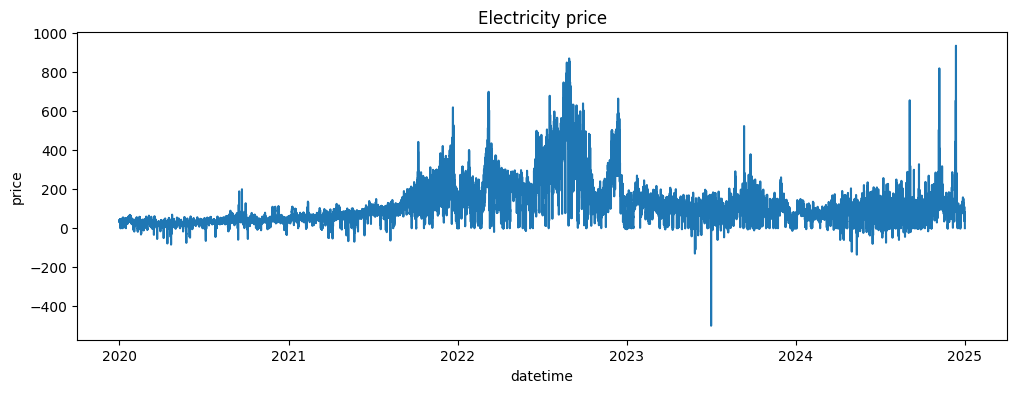

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(df1['datetime'], df1['price'])
plt.title('Electricity price')
plt.xlabel('datetime')
plt.ylabel('price')
plt.show()

## 3. Price Discretisation

The RL model requires discrete price states. We map continuous hourly prices into three regimes: **Low**, **Mid**, and **High**.

**Method:** 33rd and 67th percentile quantiles as boundaries. This ensures roughly equal state frequencies (~14,500 observations each), which gives statistically stable transition probability estimates. A fixed boundary approach would risk highly unequal state distributions given the skewed price data (especially the 2022 spike).

In [3]:
df1["price"].describe()
df1["price"].isna().sum()
q33 = df1["price"].quantile(0.33)
q67 = df1["price"].quantile(0.67)
print(q33, q67)
conditions = [df1["price"] < q33, (df1["price"] >= q33) & (df1["price"] <= q67), df1["price"] > q67]
choices = ["Low", "Mid", "High"]
df1["state"] = np.select(conditions, choices, default= "Unknown")
print(df1.head(10))

53.5651 108.3
             datetime  price state
0 2020-01-01 00:00:00  41.88   Low
1 2020-01-01 01:00:00  38.60   Low
2 2020-01-01 02:00:00  36.55   Low
3 2020-01-01 03:00:00  32.32   Low
4 2020-01-01 04:00:00  30.85   Low
5 2020-01-01 05:00:00  30.14   Low
6 2020-01-01 06:00:00  30.17   Low
7 2020-01-01 07:00:00  30.00   Low
8 2020-01-01 08:00:00  30.65   Low
9 2020-01-01 09:00:00  30.65   Low


In [4]:
df1["state"].value_counts()

,count
state,
Mid,14909
Low,14470
High,14469


In [5]:
df1["next_state"] = df1["state"].shift(-1)
df2 = df1.dropna()

## 4. Representative Price per State

Each price state needs a single representative value for the reward function in the RL model. We use the **median** rather than the mean, because the price distribution is heavily right-skewed (the 2022 crisis spike pulls the mean upward). The median is more robust to outliers and better represents the typical price a battery operator would face within each regime.

In [6]:
df2.groupby("state")["price"].median()

,price
state,
High,174.50
Low,29.95
Mid,81.76


## 5. Markov Transition Matrix Estimation

I estimate the one-step transition probabilities between price states by counting observed state transitions in the hourly data. For each consecutive pair of hours, I record whether the price moved from Low→Low, Low→Mid, etc., then normalise each row to sum to 1.

**Key finding:** The empirical matrix shows much stronger diagonal entries (~0.93/0.86/0.92) compared to the stylised values (0.6) used in the original model. This reflects the well-known **price persistence** in electricity markets — once in a price regime, the market tends to remain there for several consecutive hours. This has important implications for the Q-Learning algorithm, as discussed in `DORL_Xin_Sui.ipynb`.

In [7]:
P_real = pd.crosstab(df2["state"], df2["next_state"], normalize="index").loc[["Low", "Mid", "High"], ["Low", "Mid", "High"]].values
print(P_real.round(4))

[[9.359e-01 6.370e-02 3.000e-04]
 [6.210e-02 8.571e-01 8.080e-02]
 [1.000e-04 8.360e-02 9.164e-01]]


## Summary

This notebook produces two key parameters for the real-data version of the Q Learning model:

| Parameter | Stylised (original) | Empirical (this notebook) |
|-----------|-------------------|--------------------------|
| Low price | 30 €/MWh | 29.95 €/MWh |
| Mid price | 60 €/MWh | 81.76 €/MWh |
| High price | 100 €/MWh | 174.50 €/MWh |
| P diagonal | 0.6 / 0.6 / 0.6 | 0.936 / 0.857 / 0.916 |

The most significant difference is the transition matrix: real electricity prices exhibit far stronger regime persistence than the stylised model assumed. This finding motivated the algorithmic improvements in `DORL_Xin_Sui.ipynb` — specifically the introduction of epsilon decay and per-state-action adaptive learning rates to handle the exploration challenges posed by high price persistence.